# 4Bv5 — Fixed 4Av5 Absolute-Summarized-ESN + Thermal Analysis

This notebook loads the single shared ESN–XGBoost configuration selected by 4Av5
and performs fixed-parameter diagnostic evaluation. It does **not** optimize or
change any hyperparameter.

The combined model exactly reproduces the 4Av5 representation:

- direct absolute Savitzky–Golay-smoothed inputs, without baseline centering,
  min–max scaling, or `StandardScaler`;
- contact-aligned 0–3 s window;
- two ESN input channels: smoothed absolute `P` and `dP/dt`;
- nine trajectory summaries per reservoir unit;
- 27 scalar thermal features and `Temperature_C`; and
- the reservoir seeds and fixed ESN/XGBoost parameters saved by 4Av5.

The held-out-material protocol is the direct fixed-parameter companion to 4Av5.
Held-out-repetition and held-out-temperature protocols are secondary diagnostics.


# 1. Imports and experiment configuration


In [63]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

#


In [64]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
PARAMETER_TARGET = "eff"
RANDOM_STATE = 42

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (cwd, cwd.parent) if (path / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "multi_temp_esn"
temperature_tag = "-".join(TEMPERATURE_FOLDERS)
PARAMETER_FILE = RESULTS_DIR / (
    f"{temperature_tag}_{PARAMETER_TARGET}_4av5_primary_dprimary_absolute_smoothed_0to3_"
    "summarized_esn_thermal_optuna_tpe_mlflow_parameters.json"
)
RESULT_STEM = (
    f"{temperature_tag}_{PARAMETER_TARGET}_4bv5_fixed_primary_dprimary_absolute_smoothed_0to3_"
    "summarized_esn_thermal"
)
if not PARAMETER_FILE.is_file():
    raise FileNotFoundError(
        f"Missing 4Av5 parameter file:\n{PARAMETER_FILE}\n"
        "Copy the completed 4Av5 results/multi_temp_esn files from the other computer first."
    )

with PARAMETER_FILE.open() as file:
    SAVED_CONFIGURATION = json.load(file)
if tuple(SAVED_CONFIGURATION["temperature_folders"]) != TEMPERATURE_FOLDERS:
    raise ValueError("Saved temperature folders do not match TEMPERATURE_FOLDERS.")
if SAVED_CONFIGURATION["target"] != PARAMETER_TARGET:
    raise ValueError("Saved target does not match PARAMETER_TARGET.")

ANALYSIS_WINDOW = tuple(SAVED_CONFIGURATION["analysis_window"])
EARLY_WINDOW = tuple(SAVED_CONFIGURATION["thermal_windows"]["early"])
MID_WINDOW = tuple(SAVED_CONFIGURATION["thermal_windows"]["mid"])
LATE_WINDOW = tuple(SAVED_CONFIGURATION["thermal_windows"]["late"])
EXPECTED_SUMMARIES = (
    "mean", "std", "min", "max", "initial", "net_change", "slope",
    "mean_abs", "abs_auc",
)

if not np.allclose(ANALYSIS_WINDOW, (0.0, 3.0)):
    raise ValueError(f"4Bv5 requires analysis_window [0, 3], got {ANALYSIS_WINDOW}.")
if tuple(SAVED_CONFIGURATION.get("summary_features", ())) != EXPECTED_SUMMARIES:
    raise ValueError("The parameter JSON does not contain the expected nine 4Av5 summaries.")
preprocessing = str(SAVED_CONFIGURATION.get("input_preprocessing", "")).lower()
if not all(token in preprocessing for token in ("absolute", "no baseline", "no", "standardscaler")):
    raise ValueError("The parameter JSON does not declare the expected direct absolute preprocessing.")
if len(SAVED_CONFIGURATION.get("thermal_feature_names", ())) != 27:
    raise ValueError("The parameter JSON must declare exactly 27 scalar thermal features.")
if SAVED_CONFIGURATION.get("esn_input_channels") != ["Primary", "dPrimary/dt"]:
    raise ValueError("4Bv5 requires the revised 4Av5 P + dP/dt ESN input configuration.")

ESN_PARAMETERS = SAVED_CONFIGURATION["esn_parameters"]
ESN_RES_SIZE = int(ESN_PARAMETERS["res_size"])
ESN_LEAK_RATE = float(ESN_PARAMETERS["leak_rate"])
ESN_INPUT_MAGNITUDE = float(ESN_PARAMETERS["input_magnitude"])
ESN_SPECTRAL_RADIUS = float(ESN_PARAMETERS["spectral_radius"])
ESN_WASHOUT = int(ESN_PARAMETERS["washout"])
XGB_PARAMS = SAVED_CONFIGURATION["xgb_parameters"]
RESERVOIR_SEEDS = tuple(int(seed) for seed in SAVED_CONFIGURATION["reservoir_seeds"])
REGRESSION_TARGETS = (PARAMETER_TARGET,)

print("Loaded:", PARAMETER_FILE)
print("Analysis window:", ANALYSIS_WINDOW)
print("ESN parameters:", ESN_PARAMETERS)
print("XGBoost parameters:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)
print("Representation audit: absolute P + dP/dt; 9 ESN summaries + 27 thermal + temperature")


Loaded: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_4av5_primary_dprimary_absolute_smoothed_0to3_summarized_esn_thermal_optuna_tpe_mlflow_parameters.json
Analysis window: (0.0, 3.0)
ESN parameters: {'res_size': 10, 'leak_rate': 0.6946377960167112, 'input_magnitude': 1.6495680356466318, 'spectral_radius': 0.7604674118595436, 'washout': 0}
XGBoost parameters: {'n_estimators': 417, 'max_depth': 5, 'learning_rate': 0.05902664355935255, 'min_child_weight': 6.789451831925575, 'subsample': 0.894777681426182, 'colsample_bytree': 0.4531911880987879, 'reg_alpha': 0.027656783476788523, 'reg_lambda': 0.03548382994774278}
Reservoir seeds: (42, 43, 44)
Representation audit: absolute P + dP/dt; 9 ESN summaries + 27 thermal + temperature


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [65]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
load_rows = []

for temperature in TEMPERATURE_FOLDERS:
    folder = DATA_ROOT / temperature
    for path in sorted(folder.glob("*.csv")):
        frame = pd.read_csv(path)
        missing = required - set(frame.columns)
        if missing:
            warnings.warn(
                f"Skipping {temperature}/{path.name}; missing {sorted(missing)}"
            )
            continue
        frame["Temperature"] = temperature
        frame["source_file"] = path.name
        frames.append(frame)
        load_rows.append({
            "Temperature": temperature,
            "file": path.name,
            "rows_loaded": len(frame),
        })

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
DATA["Temperature_C"] = pd.to_numeric(
    DATA["Temperature"].str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)
if DATA["Temperature_C"].isna().any():
    raise ValueError("A temperature-folder name could not be converted to Celsius.")

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Ignore processed-file property cells and apply one standard table everywhere.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

# Temperature is required in the ID because material/trial numbers repeat by folder.
DATA["trial_id"] = (
    DATA["Temperature"].astype(str)
    + "__" + DATA["Sample"].astype(str)
    + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["Temperature", "trial_id", "Time"]).reset_index(drop=True)

summary = (
    DATA.groupby(["trial_id", "Temperature", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
temperature_summary = (
    summary.groupby("Temperature", as_index=False)
    .agg(
        trials=("trial_id", "nunique"),
        materials=("Sample", "nunique"),
        minimum_timesteps=("n_timesteps", "min"),
        maximum_timesteps=("n_timesteps", "max"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Unique temperature-specific trials: {DATA['trial_id'].nunique()}")
display(temperature_summary)


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 70,480
Unique temperature-specific trials: 336


,Temperature,trials,materials,minimum_timesteps,maximum_timesteps
0,30C,84,14,184,227
1,40C,84,14,200,362
2,50C,84,14,183,404
3,60C,84,14,186,326


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–5 second response after contact. Trials are never aligned using `k` or `eff`.


In [66]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])


In [67]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())


Aligned trials retained: 336


,trial_id,Temperature,Temperature_C,Sample,Trial,contact_time,n_analysis_samples
0,30C__aluminum_trial_1,30C,30.0,aluminum,1,8.40066,30
1,30C__aluminum_trial_2,30C,30.0,aluminum,2,7.40070,30
2,30C__aluminum_trial_3,30C,30.0,aluminum,3,7.70070,31
3,30C__aluminum_trial_4,30C,30.0,aluminum,4,8.70070,31
4,30C__aluminum_trial_5,30C,30.0,aluminum,5,7.20070,31


## Check several alignments visually


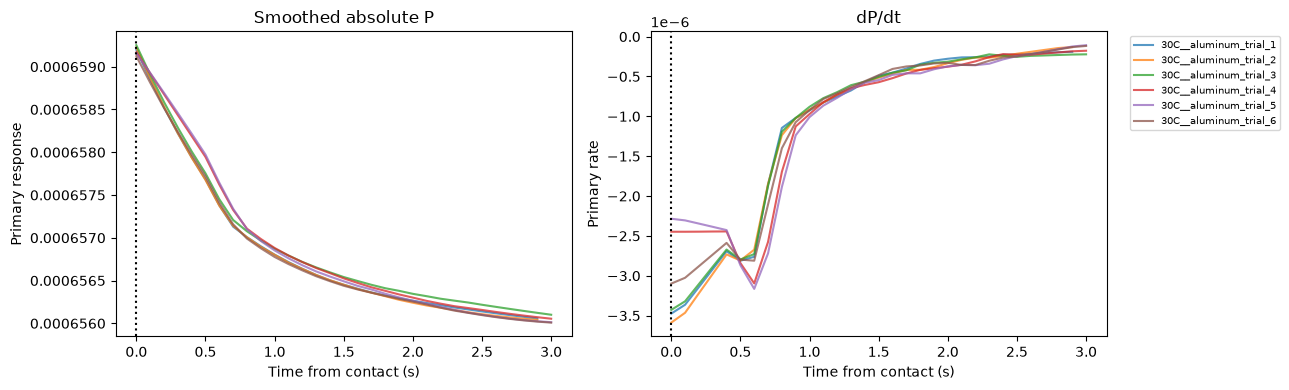

In [68]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    def smooth_for_plot(values, window=11, polyorder=2):
        values = np.asarray(values, float)
        selected_window = min(window, len(values))
        if selected_window % 2 == 0:
            selected_window -= 1
        return (savgol_filter(values, selected_window, polyorder, mode="interp")
                if selected_window >= 5 else values.copy())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        time = trial["time_from_contact"].to_numpy(float)
        primary = smooth_for_plot(trial["Primary"].to_numpy(float))
        axes[0].plot(time, primary, alpha=0.75, label=label)
        axes[1].plot(time, np.gradient(primary, time), alpha=0.75, label=label)
    for ax, title, ylabel in zip(axes, ["Smoothed absolute P", "dP/dt"],
                                  ["Primary response", "Primary rate"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel=ylabel, title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])


# 4. Interpretable thermal-response features


In [69]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _slope(time, values, window):
    mask = (time >= window[0]) & (time <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_early_slope"] = _slope(time, signal, EARLY_WINDOW)
        result[f"{name}_mid_slope"] = _slope(time, signal, MID_WINDOW)
        result[f"{name}_late_slope"] = _slope(time, signal, LATE_WINDOW)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 7}")
display(THERMAL_FEATURES.head())


Thermal features: 27


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_early_slope,primary_mid_slope,primary_late_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,...,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Temperature,Temperature_C,Sample,Trial,k,eff
0,-0.000003,0.000003,0.000007,-0.000002,-5.608193e-07,-2.301865e-07,0.000003,0.000003,-7.393007e-07,7.393007e-07,...,0.108039,-0.000040,-0.000043,30C__aluminum_trial_1,30C,30.0,aluminum,1,237.0,23958.094665
1,-0.000003,0.000003,0.000007,-0.000002,-5.356806e-07,-2.233930e-07,0.000004,0.000003,-7.777622e-07,7.777622e-07,...,0.126702,-0.000040,-0.000043,30C__aluminum_trial_2,30C,30.0,aluminum,2,237.0,23958.094665
2,-0.000003,0.000003,0.000007,-0.000002,-4.910211e-07,-2.395687e-07,0.000003,0.000003,-8.261538e-07,8.261538e-07,...,0.137653,-0.000040,-0.000043,30C__aluminum_trial_3,30C,30.0,aluminum,3,237.0,23958.094665
3,-0.000003,0.000003,0.000007,-0.000002,-5.429477e-07,-2.277291e-07,0.000003,0.000003,-7.784615e-07,7.784615e-07,...,0.130203,-0.000040,-0.000043,30C__aluminum_trial_4,30C,30.0,aluminum,4,237.0,23958.094665
4,-0.000003,0.000003,0.000007,-0.000002,-5.403697e-07,-2.391434e-07,0.000003,0.000003,-8.559441e-07,8.559441e-07,...,0.151386,-0.000041,-0.000043,30C__aluminum_trial_5,30C,30.0,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir and nine compact trajectory summaries


In [70]:
class ManualReservoir:
    def __init__(
        self, res_size=30, leak_rate=0.9, input_magnitude=1.5,
        spectral_radius=1.3, washout=0, random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 2)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 2:
            raise ValueError("Expected sequence with P and dP/dt input channels.")
        if len(sequence) <= self.washout:
            raise ValueError("Washout must be smaller than the sequence length.")
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    """Direct absolute smoothed P and dP/dt; no baseline or fitted scaling."""
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    return np.column_stack([primary, np.gradient(primary, time)])


def summarize_reservoir_trajectories(time, states):
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    if states.ndim != 2 or len(time) != len(states):
        raise ValueError("Time and reservoir states must have matching rows.")
    if len(time) < 2 or np.any(~np.isfinite(time)) or np.any(np.diff(time) <= 0):
        raise ValueError("Reservoir-state time must be finite and strictly increasing.")
    if np.any(~np.isfinite(states)):
        raise ValueError("Reservoir states contain non-finite values.")

    result = {}
    for unit in range(states.shape[1]):
        values = states[:, unit]
        summaries = {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=0)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
            "initial": float(values[0]),
            "net_change": float(values[-1] - values[0]),
            "slope": float(np.polyfit(time, values, 1)[0]),
            "mean_abs": float(np.mean(np.abs(values))),
            "abs_auc": float(np.trapezoid(np.abs(values), time)),
        }
        for name, value in summaries.items():
            if not np.isfinite(value):
                raise ValueError(f"Non-finite {name} for reservoir unit {unit}.")
            result[f"esn_{name}_u{unit:03d}"] = value
    return result


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–5 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [71]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE, leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS, washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    sequence = raw_esn_input(trial)
    states = reservoir.run(sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = compute_visualization_states(
    SELECTED_TRIAL_ID
)
print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: 30C__aluminum_trial_1
Reservoir-state matrix: (30, 10)


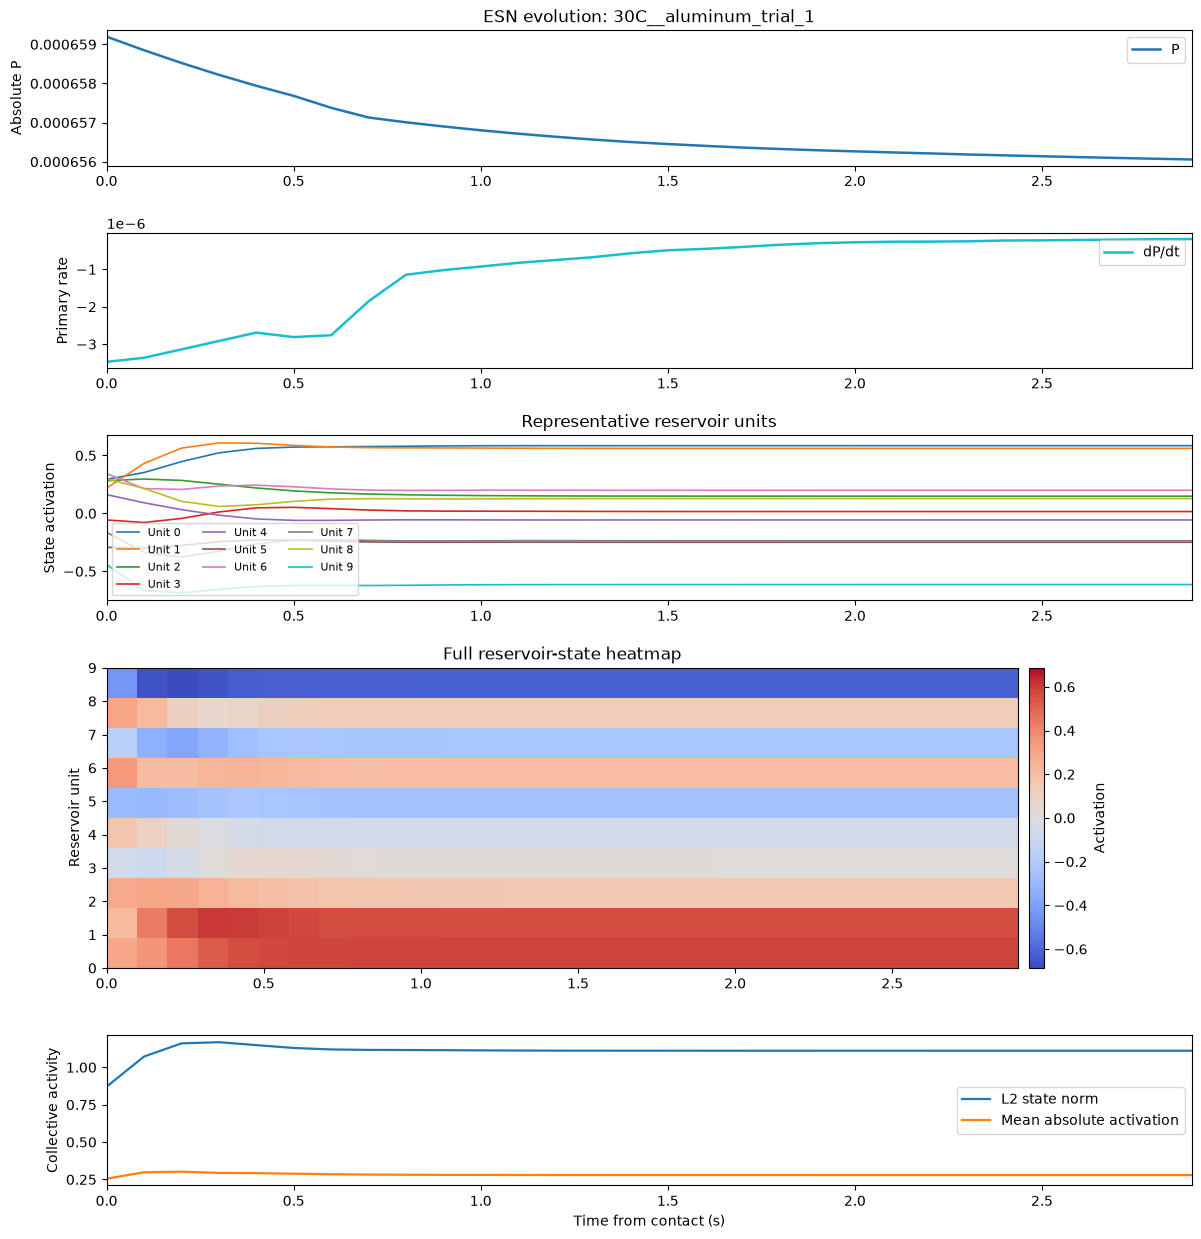

In [72]:
#def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 1,2,3,4,5,6,7,8,9,10)):    
    trial, time, direct_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 15))
    grid = fig.add_gridspec(5, 1, height_ratios=[0.9, 0.9, 1.1, 2.0, 1.0], hspace=0.38)

    # Absolute sensor response used by 4Av5/4Bv5
    ax_primary = fig.add_subplot(grid[0])
    ax_primary.plot(time, direct_inputs[:, 0], color="#1f77b4", label="P", linewidth=1.8)
    ax_primary.set(ylabel="Absolute P", title=f"ESN evolution: {trial_id}")
    ax_primary.legend(loc="best")

    ax_primary_rate = fig.add_subplot(grid[1], sharex=ax_primary)
    ax_primary_rate.plot(time, direct_inputs[:, 1], color="#17becf", label="dP/dt", linewidth=1.8)
    ax_primary_rate.set(ylabel="Primary rate")
    ax_primary_rate.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[2], sharex=ax_primary)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[3], sharex=ax_primary)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[4], sharex=ax_primary)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe fixed-parameter metrics and evaluation


In [73]:
def regression_metrics(y_true, y_pred):
    """Metrics requiring variation in y_true; intended for pooled or mixed-target data."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Metrics require non-empty, finite targets and predictions.")
    target_range = float(np.ptp(y_true))
    if len(y_true) < 2 or target_range <= 0:
        raise ValueError(
            "R² and test-range NRMSE require at least two distinct target values. "
            "Use constant_target_fold_metrics for a single-material LOMO fold."
        )
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range,
        "r2": float(r2_score(y_true, y_pred)),
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def constant_target_fold_metrics(y_true, y_pred, training_target_range):
    """Valid diagnostics for one outer LOMO fold with a constant test target."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    training_target_range = float(training_target_range)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Fold metrics require non-empty, finite values.")
    if training_target_range <= 0:
        raise ValueError("The outer-training target range must be positive.")
    residual = y_pred - y_true
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    return {
        "n": len(y_true),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": rmse,
        "nrmse_training_range": rmse / training_target_range,
        "mean_error_bias": float(np.mean(residual)),
        "median_ape_pct": float(np.median(np.abs(residual / y_true)) * 100),
    }


def make_regressor(xgb_params=None, random_state=RANDOM_STATE):
    params = {**XGB_PARAMS, **(xgb_params or {})}
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(random_state),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **params,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


In [74]:
PROTOCOL_GROUP_COLUMN = {
    "held_out_repetition": "Trial",
    "held_out_material": "Sample",
    "held_out_temperature": "Temperature",
}


def outer_splits(table, protocol):
    if protocol not in PROTOCOL_GROUP_COLUMN:
        raise ValueError(f"Unknown protocol: {protocol}")
    return LeaveOneGroupOut().split(table, groups=table[PROTOCOL_GROUP_COLUMN[protocol]])


THERMAL_PREDICTOR_COLUMNS = [
    column for column in THERMAL_FEATURES.columns
    if column not in {
        "trial_id", "Temperature", "Temperature_C", "Sample", "Trial", "k", "eff"
    }
]
if len(THERMAL_PREDICTOR_COLUMNS) != 27:
    raise ValueError(f"Expected 27 thermal predictors, got {len(THERMAL_PREDICTOR_COLUMNS)}.")
if THERMAL_PREDICTOR_COLUMNS != SAVED_CONFIGURATION["thermal_feature_names"]:
    raise ValueError("Thermal feature names/order differ from the 4Av5 parameter JSON.")


def build_esn_feature_table(train_ids, all_ids, esn_params=None, random_state=RANDOM_STATE):
    # train_ids is retained to keep the fold interface explicit; direct absolute
    # preprocessing fits no scaler and therefore learns nothing from this list.
    del train_ids
    params = {
        "res_size": ESN_RES_SIZE, "leak_rate": ESN_LEAK_RATE,
        "input_magnitude": ESN_INPUT_MAGNITUDE,
        "spectral_radius": ESN_SPECTRAL_RADIUS, "washout": ESN_WASHOUT,
    }
    params.update(esn_params or {})
    reservoir = ManualReservoir(**params, random_state=random_state)
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        states = reservoir.run(raw_esn_input(trial))
        state_time = trial["time_from_contact"].to_numpy(float)[params["washout"]:]
        features = summarize_reservoir_trajectories(state_time, states)
        features.update({
            "trial_id": trial_id, "Temperature": trial["Temperature"].iloc[0],
            "Temperature_C": float(trial["Temperature_C"].iloc[0]),
            "Sample": trial["Sample"].iloc[0], "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]), "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_feature_family(feature_family, target, protocol):
    metadata_columns = [
        "trial_id", "Temperature", "Temperature_C", "Sample", "Trial", "k", "eff",
    ]
    metadata = THERMAL_FEATURES[metadata_columns].copy()
    group_column = PROTOCOL_GROUP_COLUMN[protocol]
    fold_rows, prediction_rows = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_splits(metadata, protocol), start=1):
        train_meta, test_meta = metadata.iloc[train_idx], metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()
        if set(train_meta[group_column]) & set(test_meta[group_column]):
            raise RuntimeError(f"{group_column} leakage detected.")
        y_train = train_meta[target].reset_index(drop=True)
        y_test = test_meta[target].reset_index(drop=True)

        if feature_family == "thermal":
            indexed = THERMAL_FEATURES.set_index("trial_id")
            feature_columns = ["Temperature_C"] + THERMAL_PREDICTOR_COLUMNS
            X_train = indexed.loc[train_ids, feature_columns].reset_index(drop=True)
            X_test = indexed.loc[test_ids, feature_columns].reset_index(drop=True)
            model = make_regressor(xgb_params=XGB_PARAMS, random_state=RANDOM_STATE)
            model.fit(X_train, y_train)
            pred = np.clip(model.predict(X_test), y_train.min(), y_train.max())
        elif feature_family == "combined":
            seed_predictions = []
            for random_state in RESERVOIR_SEEDS:
                esn = build_esn_feature_table(
                    train_ids, train_ids + test_ids, random_state=random_state
                ).set_index("trial_id")
                esn_columns = [column for column in esn.columns if column.startswith("esn_")]
                expected_esn_count = 9 * ESN_RES_SIZE
                if len(esn_columns) != expected_esn_count:
                    raise ValueError(
                        f"Expected {expected_esn_count} ESN summaries, got {len(esn_columns)}."
                    )
                combined = esn.join(
                    THERMAL_FEATURES.set_index("trial_id")[THERMAL_PREDICTOR_COLUMNS],
                    how="left", validate="one_to_one",
                )
                # Exact 4Av5 ordering matters when XGBoost uses column subsampling.
                feature_columns = ["Temperature_C"] + esn_columns + THERMAL_PREDICTOR_COLUMNS
                X_train = combined.loc[train_ids, feature_columns].reset_index(drop=True)
                X_test = combined.loc[test_ids, feature_columns].reset_index(drop=True)
                seed_y_train = combined.loc[train_ids, target].reset_index(drop=True)
                if not np.allclose(seed_y_train, y_train):
                    raise RuntimeError("Target alignment changed across ESN seeds.")
                model = make_regressor(xgb_params=XGB_PARAMS, random_state=random_state)
                model.fit(X_train, y_train)
                seed_predictions.append(np.clip(
                    model.predict(X_test), y_train.min(), y_train.max()
                ))
            pred = np.mean(seed_predictions, axis=0)
        else:
            raise ValueError("feature_family must be thermal or combined")

        diagnostics = (
            constant_target_fold_metrics(y_test, pred, np.ptp(y_train.to_numpy(float)))
            if protocol == "held_out_material" else regression_metrics(y_test, pred)
        )
        fold_rows.append({
            "fold": fold, "feature_family": feature_family, "target": target,
            "protocol": protocol,
            "held_out_group": ", ".join(sorted(str(x) for x in test_meta[group_column].unique())),
            **diagnostics,
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids, "Temperature": test_meta["Temperature"].to_numpy(),
            "Temperature_C": test_meta["Temperature_C"].to_numpy(),
            "Sample": test_meta["Sample"].to_numpy(), "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold, "y_true": y_test.to_numpy(), "y_pred": pred,
        }))

    folds = pd.DataFrame(fold_rows)
    predicted = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": feature_family, "target": target, "protocol": protocol,
        **regression_metrics(predicted["y_true"], predicted["y_pred"]),
    }])
    return folds, overall, predicted


# 8. Run fixed-parameter diagnostic protocols


In [75]:
PROTOCOLS = (
    "held_out_repetition", "held_out_material", "held_out_temperature",
)
FEATURE_FAMILIES = ("thermal", "combined")
all_results, fold_metrics, predictions = [], {}, {}
for protocol in PROTOCOLS:
    print(f"Running {protocol}...")
    for family in FEATURE_FAMILIES:
        for target in REGRESSION_TARGETS:
            folds, overall, predicted = evaluate_feature_family(family, target, protocol)
            all_results.append(overall)
            fold_metrics[(protocol, family, target)] = folds
            predictions[(protocol, family, target)] = predicted
ALL_RESULTS = pd.concat(all_results, ignore_index=True)
display(ALL_RESULTS.sort_values(["protocol", "feature_family"]).reset_index(drop=True))

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ALL_RESULTS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv", index=False)
for (protocol, family, target), table in fold_metrics.items():
    table.to_csv(
        RESULTS_DIR / f"{RESULT_STEM}_{protocol}_{family}_{target}_fold_metrics.csv",
        index=False,
    )
for (protocol, family, target), table in predictions.items():
    table.to_csv(
        RESULTS_DIR / f"{RESULT_STEM}_{protocol}_{family}_{target}_oof_predictions.csv",
        index=False,
    )

LOMO_COMBINED_OOF_FILE = RESULTS_DIR / (
    f"{RESULT_STEM}_held_out_material_combined_{PARAMETER_TARGET}_oof_predictions.csv"
)
print("Saved canonical 4Bv5 LOMO combined-feature OOF predictions:")
print(LOMO_COMBINED_OOF_FILE)


Running held_out_repetition...
Running held_out_material...
Running held_out_temperature...


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,combined,eff,held_out_material,336,4178.105774,7691.848353,0.207003,0.529034,48.897457
1,thermal,eff,held_out_material,336,4234.167827,7755.771346,0.208724,0.521174,49.318279
2,combined,eff,held_out_repetition,336,2884.066807,5670.808152,0.152613,0.744013,27.439362
3,thermal,eff,held_out_repetition,336,2863.683174,5545.004335,0.149227,0.755245,23.955456
4,combined,eff,held_out_temperature,336,6723.798159,11048.334174,0.297333,0.028324,72.367555
5,thermal,eff,held_out_temperature,336,5999.612775,10517.958136,0.283060,0.119375,70.117083


Saved canonical 4Bv5 LOMO combined-feature OOF predictions:
/Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_4bv5_fixed_primary_dprimary_absolute_smoothed_0to3_summarized_esn_thermal_held_out_material_combined_eff_oof_predictions.csv


# 9. LOMO material and temperature diagnostics


In [76]:
lomo_material_rows = []
lomo_temperature_rows = []
for family in FEATURE_FAMILIES:
    for target in REGRESSION_TARGETS:
        oof = predictions[("held_out_material", family, target)]
        by_material = oof.groupby("Sample", as_index=False).agg(
            y_true=("y_true", "mean"), y_pred=("y_pred", "mean"),
            prediction_sd=("y_pred", "std"), n_trials=("trial_id", "size"),
        )
        lomo_material_rows.append({
            "feature_family": family, "target": target,
            **regression_metrics(by_material["y_true"], by_material["y_pred"]),
        })
        for temperature, part in oof.groupby("Temperature", sort=True):
            lomo_temperature_rows.append({
                "feature_family": family, "target": target, "Temperature": temperature,
                **regression_metrics(part["y_true"], part["y_pred"]),
            })

LOMO_MATERIAL_MEAN_RESULTS = pd.DataFrame(lomo_material_rows)
LOMO_TEMPERATURE_RESULTS = pd.DataFrame(lomo_temperature_rows)
LOMO_PER_MATERIAL_FOLDS = pd.concat([
    fold_metrics[("held_out_material", family, target)]
    for family in FEATURE_FAMILIES for target in REGRESSION_TARGETS
], ignore_index=True)

print("LOMO after averaging 24 OOF trials per material:")
display(LOMO_MATERIAL_MEAN_RESULTS)
print("LOMO pooled separately by operating temperature:")
display(LOMO_TEMPERATURE_RESULTS)
print("Valid per-material fold diagnostics (R² intentionally absent):")
display(LOMO_PER_MATERIAL_FOLDS.sort_values(["feature_family", "rmse"], ascending=[True, False]))


LOMO after averaging 24 OOF trials per material:


,feature_family,target,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,eff,14,3089.991313,6688.158990,0.179992,0.643925,52.182506
1,combined,eff,14,3424.919932,6774.913834,0.182327,0.634628,64.327926


LOMO pooled separately by operating temperature:


,feature_family,target,Temperature,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,eff,30C,84,3806.001453,7784.854723,0.209506,0.517576,48.661783
1,thermal,eff,40C,84,4987.926272,8660.166733,0.233063,0.402991,47.142169
2,thermal,eff,50C,84,4359.370007,8029.888844,0.216101,0.486729,50.210241
3,thermal,eff,60C,84,3783.373575,6366.034161,0.171323,0.677399,51.305351
4,combined,eff,30C,84,3494.054183,7179.720664,0.193221,0.589661,45.828317
5,combined,eff,40C,84,4650.328275,8194.668584,0.220535,0.465447,46.724585
6,combined,eff,50C,84,4390.911945,8277.911308,0.222775,0.454532,47.756821
7,combined,eff,60C,84,4177.128693,7030.883778,0.189215,0.606497,59.072706


Valid per-material fold diagnostics (R² intentionally absent):


,fold,feature_family,target,protocol,held_out_group,n,mae,rmse,nrmse_training_range,mean_error_bias,median_ape_pct
17,4,combined,eff,held_out_material,copper,24,23001.015502,23505.593579,0.982528,-23001.015502,61.685332
14,1,combined,eff,held_out_material,aluminum,24,7876.470960,8832.615582,0.237704,-6031.405438,37.535131
15,2,combined,eff,held_out_material,bismuth,24,6419.324118,7171.946584,0.193012,6396.471391,224.836140
26,13,combined,eff,held_out_material,titanium,24,5855.261106,6998.532949,0.188345,4799.860310,58.507581
21,8,combined,eff,held_out_material,iron,24,5016.201341,6473.548205,0.174216,1246.042255,26.346062
22,9,combined,eff,held_out_material,nickel,24,4789.860277,5755.800451,0.154900,-2509.782303,25.752680
19,6,combined,eff,held_out_material,graphite,24,3116.655791,3667.491166,0.098700,-2000.849075,27.649202
27,14,combined,eff,held_out_material,wood,24,1378.196892,2907.694568,0.078252,1098.408423,47.902678
20,7,combined,eff,held_out_material,gypsum,24,298.149040,467.627959,0.012585,271.004230,53.304815
23,10,combined,eff,held_out_material,pdms,24,200.544918,233.998608,0.006297,-198.762427,42.137515


# 10. Actual-versus-predicted comparisons


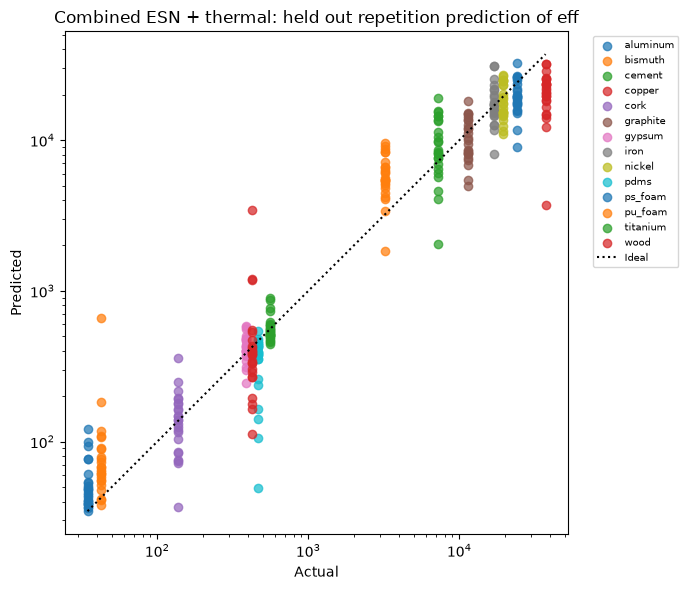

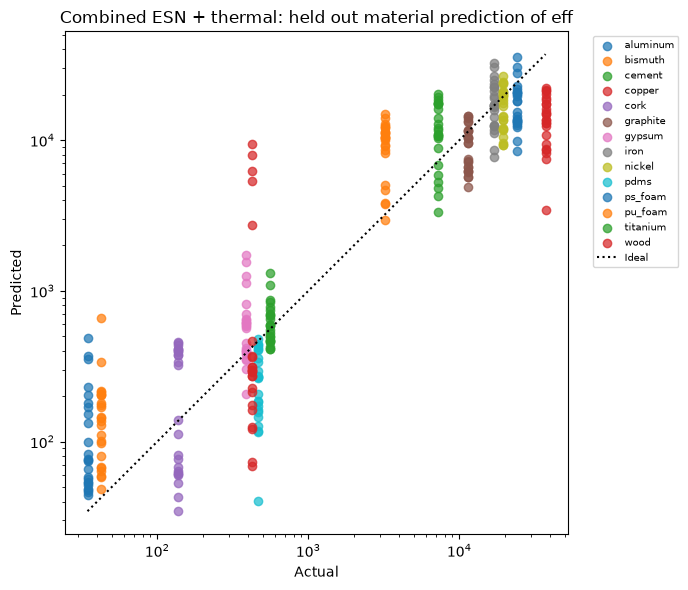

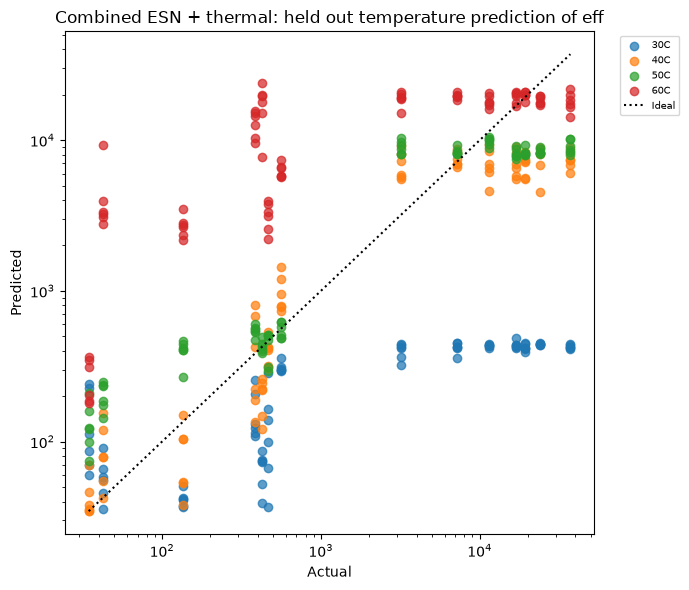

In [77]:
def plot_actual_predicted(predicted, title, color_column):
    shown = predicted[
        (predicted["y_true"] > 0) & (predicted["y_pred"] > 0)
    ].copy()
    if shown.empty:
        warnings.warn(f"No positive actual/predicted values to plot: {title}")
        return

    fig, ax = plt.subplots(figsize=(7, 6))
    for label, part in shown.groupby(color_column, sort=True):
        ax.scatter(
            part["y_true"], part["y_pred"],
            label=str(label), alpha=0.72,
        )
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], "k:", label="Ideal")
    ax.set(
        xscale="log", yscale="log",
        xlabel="Actual", ylabel="Predicted", title=title,
    )
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


for protocol in PROTOCOLS:
    color_column = "Temperature" if protocol == "held_out_temperature" else "Sample"
    for target in REGRESSION_TARGETS:
        plot_actual_predicted(
            predictions[(protocol, "combined", target)],
            f"Combined ESN + thermal: {protocol.replace('_', ' ')} prediction of {target}",
            color_column,
        )


# 11. Compare protocols


In [78]:
comparison = ALL_RESULTS.pivot_table(
    index=["feature_family", "target"], columns="protocol",
    values=["r2", "nrmse_range", "mae"],
)
display(comparison)


mae                      \
protocol              held_out_material held_out_repetition   
feature_family target                                         
combined       eff          4178.105774         2884.066807   
thermal        eff          4234.167827         2863.683174   

                                                 nrmse_range  \
protocol              held_out_temperature held_out_material   
feature_family target                                          
combined       eff             6723.798159          0.207003   
thermal        eff             5999.612775          0.208724   

                                                                \
protocol              held_out_repetition held_out_temperature   
feature_family target                                            
combined       eff               0.152613             0.297333   
thermal        eff               0.149227             0.283060   

                                     r2                      \
protocol              held_out_material held_out_repetition   
feature_family target                                         
combined       eff             0.529034            0.744013   
thermal        eff             0.521174            0.755245   

                                            
protocol              held_out_temperature  
feature_family target                       
combined       eff                0.028324  
thermal        eff                0.119375

# 12. Interpretation and provenance

- No hyperparameter optimization occurs here; all settings come from the 4Av5 JSON.
- `combined` is the exact 4Av5 representation: temperature + summarized ESN + thermal.
- `thermal` is a descriptive fixed-parameter comparator and does not replace the combined model.
- Held-out-material results are the primary matching LOMO diagnostics.
- Held-out-repetition and held-out-temperature results answer different generalization questions.
- Per-material fold R² is undefined because each held-out material has a constant target;
  use its MAE, RMSE, training-range NRMSE, bias, and percentage error.
- Hyperparameters were selected using 4Av5 LOMO, so these are fixed-pipeline diagnostics,
  not a new untouched external test estimate.
